<a href="https://colab.research.google.com/github/Ghasthydra/99-/blob/main/Prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
mnist = tf.keras.datasets.mnist

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# ... Definir el modelo CCN

# Compilar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Añadir callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)
]

# Entrenamiento con más épocas y validación
model.fit(x_train, y_train,
          epochs=15,
          validation_split=0.1,
          batch_size=128,
          callbacks=callbacks)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.8432 - loss: 0.5257 - val_accuracy: 0.9808 - val_loss: 0.0711 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 95ms/step - accuracy: 0.9769 - loss: 0.0773 - val_accuracy: 0.9878 - val_loss: 0.0479 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.9832 - loss: 0.0565 - val_accuracy: 0.9900 - val_loss: 0.0396 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9867 - loss: 0.0407 - val_accuracy: 0.9898 - val_loss: 0.0377 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.9895 - loss: 0.0328 - val_accuracy: 0.9905 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9915 - loss: 0.0266 - val_accuracy: 0.9910 - val_loss: 0.0353 - learning_rate: 0.0010
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.9934 - l

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


<ipython-input-30-b9c2f66bfbad>:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


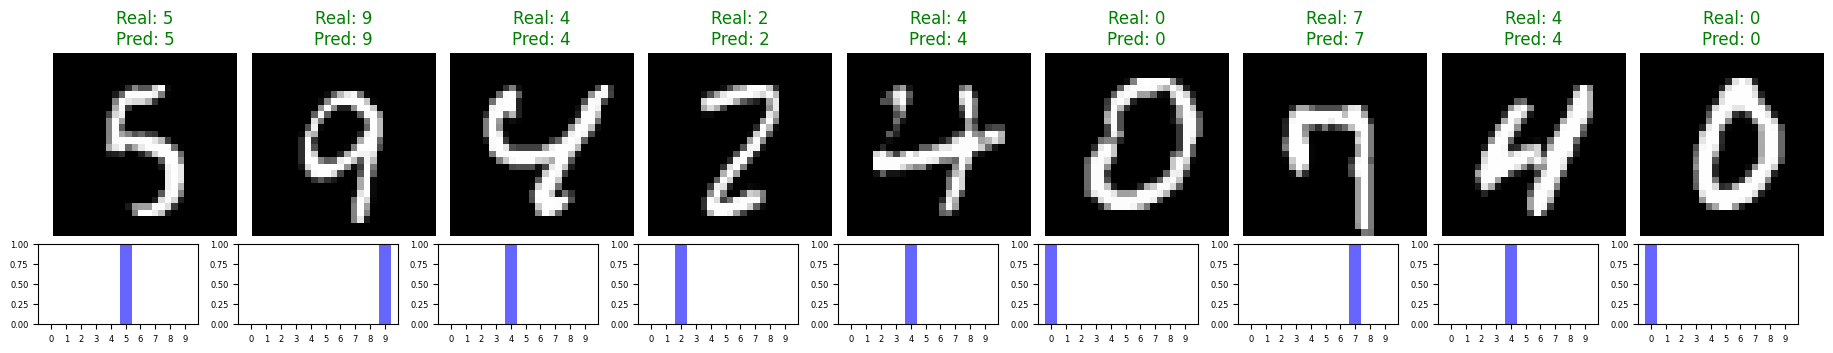

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Precisión global (Accuracy): 0.9930
Precisión (Weighted Precision): 0.9930
Recall (Weighted Recall): 0.9930
F1-Score (Weighted F1): 0.9930

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



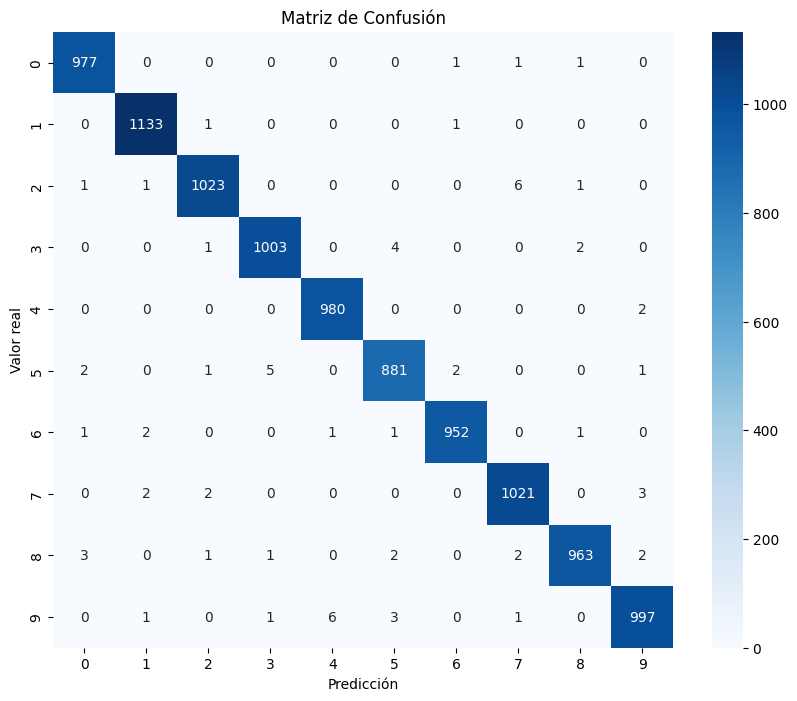

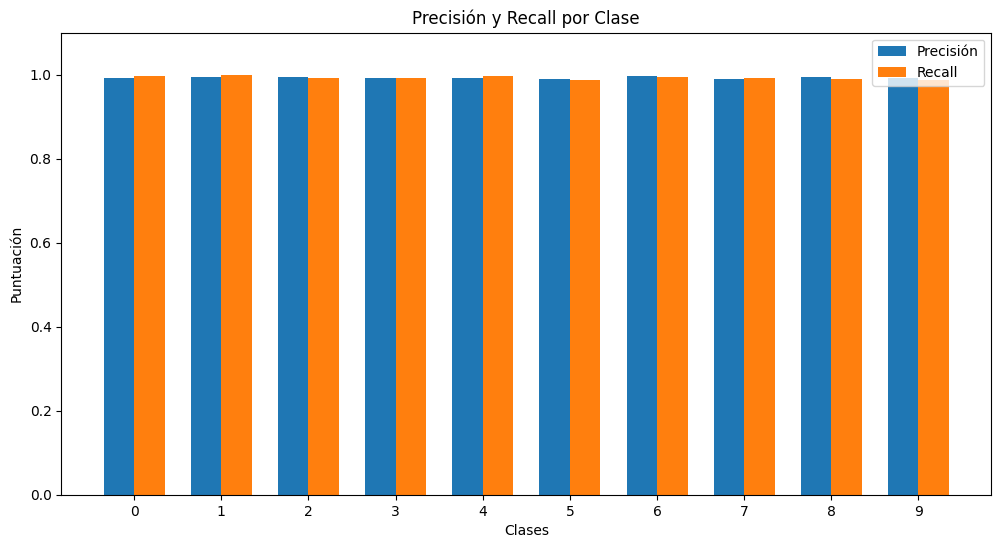

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Función para mostrar predicciones (correctly defined earlier, keeping here for completeness)


# Función para visualizar matrices de confusión (correctly defined earlier, keeping here for completeness)



def evaluate_model(model, x_test, y_test, class_names=None):
    """
    Evalúa un modelo de clasificación y muestra varias métricas de rendimiento.

    Args:
        model: Modelo entrenado a evaluar
        x_test: Datos de prueba (features)
        y_test: Etiquetas reales de prueba
        class_names: Lista con los nombres de las clases (opcional)
    """
    # Hacer predicciones
    y_pred = np.argmax(model.predict(x_test), axis=1)
    y_true = y_test

    # Calcular métricas globales
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Precisión global (Accuracy): {accuracy:.4f}")
    print(f"Precisión (Weighted Precision): {precision:.4f}")
    print(f"Recall (Weighted Recall): {recall:.4f}")
    print(f"F1-Score (Weighted F1): {f1:.4f}\n")

    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicción')
    plt.ylabel('Valor real')
    plt.title('Matriz de Confusión')
    plt.show()

    # Precisión por clase
    precision_per_class = precision_score(y_true, y_pred, average=None)
    recall_per_class = recall_score(y_true, y_pred, average=None)

    # Gráfico de precisión y recall por clase
    plt.figure(figsize=(12, 6))
    x = range(len(precision_per_class))
    width = 0.35

    plt.bar([i - width/2 for i in x], precision_per_class, width, label='Precisión')
    plt.bar([i + width/2 for i in x], recall_per_class, width, label='Recall')

    plt.xlabel('Clases')
    plt.ylabel('Puntuación')
    plt.title('Precisión y Recall por Clase')
    plt.xticks(x, class_names)
    plt.legend()
    plt.ylim(0, 1.1)
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# Ejemplo de uso:
# Asumiendo que tienes nombres para tus clases (por ejemplo, dígitos 0-9)
class_names = [str(i) for i in range(10)]  # ['0', '1', ..., '9']

# Visualizar predicciones (using the corrected plot_predictions)
plot_predictions(model, x_test, y_test, num_examples=9) # Using 9 as per the last definition



# Evaluar el modelo (using the corrected evaluate_model)
metrics = evaluate_model(model, x_test, y_test, class_names=class_names)